<a href="https://colab.research.google.com/github/iccamiloandres12-lang/Proyecto_Final_Dataxperience/blob/main/Copia_de_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyeto Final

## Análsis y predicción de superviencia en el Titanic

### 1. Selección del conjunto de datos

Decidimos elegir para nuestro proyecto el conjunto de datos de lo ocurrido con el Titanic.

El dataset contiene información sobre los pasajeros como edad, sexo, clase de pasajero, tarifa pagada, número de familiares a bordo y si el pasajero sobrevivio o no.

### 2. Justificación de elección

Elegimos este dataset porque nos permite trabajar con una problematica real, ademas contiene diferentes tipos de varibles numericas como categoricas permitiendonos realizar un desarrollo y analisis detallado de los valores faltantes, transformación de variables y evidenciar la distribución de los datos.

Por otro lado, dicha elección nos permite integrar todos los conocimientos adquiridos durante los diferentes modulos vistos en clases. De esta manera no solo analizaremos un conjunto de datos, sino que aplicaremos las diferentes etapas que se manejan en un proyeto real.

Danna: Este proyecto se relaciona con mi carrera porque me permite desarrollar habilidades fundamnetales para identificar problemas, encontrar patrones, interpretar información y utilizar diferentes modelos para tomar desiciones importante en base a los datos generando soluciones basadas en evidencia.

### 3. Exploración de los datos

En esta etapa se realizará una exploración inicial del dataset con el propósito de conocer su estructura, identificar los tipos de variables, detectar posibles problemas de calidad y observar el comportamiento inicial de los datos.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos el dataset
df_original = sns.load_dataset("titanic")
df = df_original.copy()
print("Primeras 5 filas del dataset:")
display(df.head())



Primeras 5 filas del dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### Dimensiones

In [ ]:
filas, columnas = df.shape
print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")

Número de filas: 891
Número de columnas: 15


#### Nombre de las variables

In [ ]:
for i, columna in enumerate(df.columns, start=1):
    print(f"{i}. {columna}")

1. survived
2. pclass
3. sex
4. age
5. sibsp
6. parch
7. fare
8. embarked
9. class
10. who
11. adult_male
12. deck
13. embark_town
14. alive
15. alone


#### Información general

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


#### Tipo de dato de cada variable

In [ ]:
for columna in df.columns:
    print(f"{columna}: {df[columna].dtype}")

survived: int64
pclass: int64
sex: object
age: float64
sibsp: int64
parch: int64
fare: float64
embarked: object
class: category
who: object
adult_male: bool
deck: category
embark_town: object
alive: object
alone: bool


#### Análisis estadistico inicial

In [ ]:
display(df.describe())

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Cantidad de valores nulos por variable

In [ ]:
nulos = df.isnull().sum()
for columna, cantidad in nulos.items():
    if cantidad > 0:
        print(f"{columna}: {cantidad}")

# Prcentaje Valores nulos
print("\nPorcentaje de valores nulos:")

porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)
for columna, porcentaje in porcentaje_nulos.items():
    if porcentaje > 0:
        print(f"{columna}: {porcentaje}%")


age: 177
embarked: 2
deck: 688
embark_town: 2

Porcentaje de valores nulos:
age: 19.87%
embarked: 0.22%
deck: 77.22%
embark_town: 0.22%


##### Número de resgistros duplicados


In [ ]:
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 107


#### Distribuciones iniciales

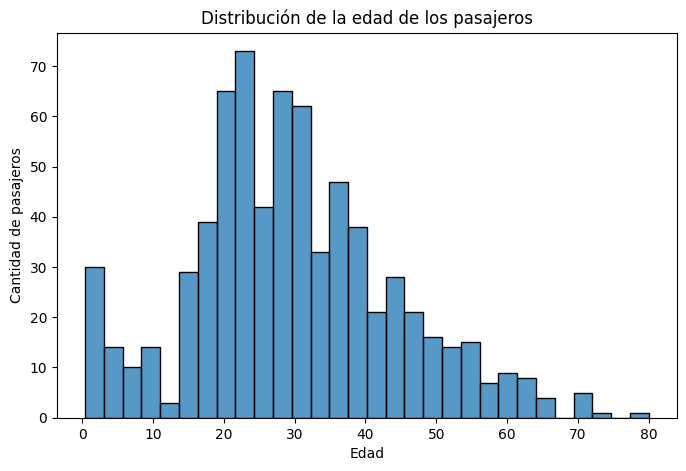

Media de edad: 29.69911764705882
Mediana de edad: 28.0
Edad mínima: 0.42
Edad máxima: 80.0


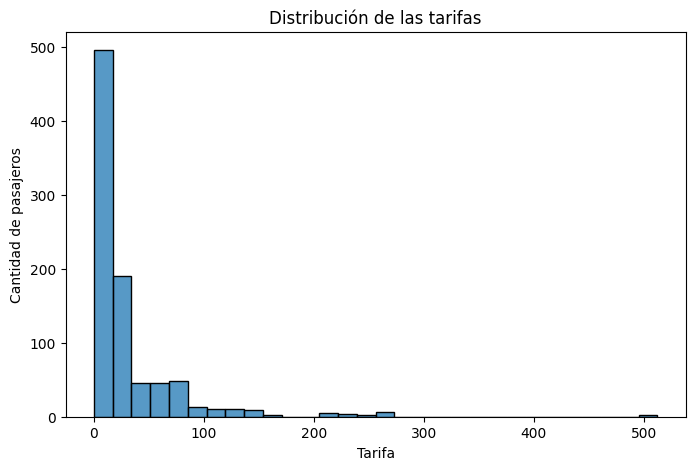

Media de tarifa: 32.20
Mediana de tarifa: 14.45
Tarifa mínima: 0.00
Tarifa máxima: 512.33


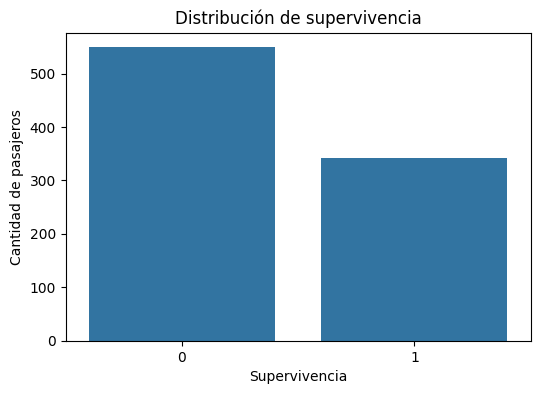

No sobrevivieron: 549
Sobrevivieron: 342


In [ ]:
# De edad
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30)
plt.title("Distribución de la edad de los pasajeros")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")
plt.show()

print("Media de edad:", df["age"].mean())
print("Mediana de edad:", df["age"].median())
print("Edad mínima:", df["age"].min())
print("Edad máxima:", df["age"].max())

# De tarifa
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="fare", bins=30)
plt.title("Distribución de las tarifas")
plt.xlabel("Tarifa")
plt.ylabel("Cantidad de pasajeros")
plt.show()

print(f"Media de tarifa: {df['fare'].mean():.2f}")
print(f"Mediana de tarifa: {df['fare'].median():.2f}")
print(f"Tarifa mínima: {df['fare'].min():.2f}")
print(f"Tarifa máxima: {df['fare'].max():.2f}")

# De supervivencia
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="survived")
plt.title("Distribución de supervivencia")
plt.xlabel("Supervivencia")
plt.ylabel("Cantidad de pasajeros")
plt.show()

print(f"No sobrevivieron: {(df['survived'] == 0).sum()}")
print(f"Sobrevivieron: {(df['survived'] == 1).sum()}")

### 4. Limpieza y transformación

A partir de la etapa anterior identificamos valores faltantes, registros duplicados y variables que requieren transformación para poder ser utilizadas posteriormente.

En esta etapa aplicaremos técnicas de limpieza y transformación con el objetivo de mejorar la calidad de los datos y preparar el dataset para el análisis predictivo.

#### Problemas identificados

Durante la exploración inicial de los datos encontramos los siguientes problemas:

1. La variable `age` presenta 177 valores faltantes (19.87%).
2. Las variables `embarked` y `embark_town` presentan 2 valores faltantes cada una (0.22%).
3. La variable `deck` presenta 688 valores faltantes (77.22%).
4. Se identificaron 107 registros duplicados.
5. Existen variables categóricas que deberán ser transformadas para poder ser utilizadas posteriormente en los modelos.
6. Algunas variables contienen información redundante o directamente relacionada con la variable objetivo.

#### Tratamiento de valores faltantes en la edad

Eliminar estas filas implicaría perder una cantidad importante de información. Por esta razón, se decidió imputar los valores faltantes utilizando la mediana de la edad, ya que esta medida es menos sensible a valores extremos que la media.

In [ ]:
df_limpio = df.copy()
print("Copia del dataset creada correctamente.")
print(f"Filas: {df_limpio.shape[0]}")
print(f"Columnas: {df_limpio.shape[1]}")

# Media de edades
mediana_edad = df_limpio["age"].median()
print(f"\nMediana de edad utilizada: {mediana_edad:.2f}")

# Completar valores faltantes
df_limpio["age"] = df_limpio["age"].fillna(mediana_edad)

# Verificar
print(f"Valores nulos restantes en 'age': {df_limpio['age'].isnull().sum()}")

Copia del dataset creada correctamente.
Filas: 891
Columnas: 15

Mediana de edad utilizada: 28.00
Valores nulos restantes en 'age': 0


#### Tratamiento de valores faltantes de embarque

Debido a que se trata de una cantidad muy pequeña se decidió completar estos valores utilizando la moda de la variable correspondiente al puerto de embarque más frecuente.

In [ ]:
# Moda
moda_embarked = df_limpio["embarked"].mode()[0]
print(f"Moda de 'embarked': {moda_embarked}")

# valores faltantes
df_limpio["embarked"] = df_limpio["embarked"].fillna(moda_embarked)

# Verificar
print(f"Valores nulos restantes en 'embarked': {df_limpio['embarked'].isnull().sum()}")

Moda de 'embarked': S
Valores nulos restantes en 'embarked': 0


#### Tratamiento de valores faltantes en cubierta

Debido a que la mayoría de los registros no contienen información sobre esta variable, imputar sus valores podría generar una gran cantidad de información estimada y afectar la calidad del análisis. Por esta razón se decidió eliminar esta variable del conjunto de datos.


In [ ]:
df_limpio = df_limpio.drop(columns=["deck"])
print("La variable 'deck' fue eliminada.")
print(f"Número de columnas actuales: {df_limpio.shape[1]}")

La variable 'deck' fue eliminada.
Número de columnas actuales: 14


#### Eliminación de la ciudad de embarque

La variable `embark_town` contiene únicamente 2 valores faltantes. Sin embargo, este problema presenta información redundante respecto a `embarked` ya que ambas variables representan el puerto de embarque.

Por esto para evitar la duplicidad de la información
decidimos conservar `embarked` y eliminar `embark_town`.


In [ ]:
df_limpio = df_limpio.drop(columns=["embark_town"])
print("La variable 'embark_town' fue eliminada.")

La variable 'embark_town' fue eliminada.


#### comprobacion de valores nulos


In [ ]:
nulos = df_limpio.isnull().sum()
for columna, cantidad in nulos.items():
    if cantidad > 0:
        print(f"{columna}: {cantidad}")
if nulos.sum() == 0:
    print("No quedan valores nulos en el dataset.")

No quedan valores nulos en el dataset.


#### Analisis de riesgos duplicados

Durante la exploración inicial se identificaron registros duplicados. Antes de eliminarlos se revisó su contenido para determinar si correspondían a observaciones completamente idénticas.

Debido a que estos registros presentan exactamente los mismos valores en las variables utilizadas para el análisis decidimos conservar una sola instancia de cada registro duplicado, de esta manera se evita otorgar un peso adicional a observaciones repetidas durante el entrenamiento de los modelos



In [ ]:
duplicados = df[df.duplicated(keep=False)]
print(f"Número de registros duplicados: {df.duplicated().sum()}")

print("\nEjemplos de registros duplicados:")
display(duplicados.head(10))

Número de registros duplicados: 107

Ejemplos de registros duplicados:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
29,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
32,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
45,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
46,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True


In [ ]:
df_limpio = df_limpio.drop_duplicates()
print("\nDuplicados despues de la limpieza")
print(f"Registros restantes: {len(df_limpio)}")
print(f"Duplicados restantes: {df_limpio.duplicated().sum()}")



Duplicados despues de la limpieza
Registros restantes: 775
Duplicados restantes: 0


#### Eliminación de información redundante y fuga de información

La variable `survived` será utilizada como variable objetivo del modelo predictivo.

La variable `alive` contiene directamente el mismo resultado expresado mediante texto. Mantenerla como variable predictora permitiría al modelo conocer de antemano la respuesta que se intenta predecir, generando una fuga de información.

Por esto `alive` será eliminada del conjunto de datos.


In [ ]:
df_limpio = df_limpio.drop(columns=["alive"])
print("La variable 'alive' fue eliminada para evitar fuga de información.")

La variable 'alive' fue eliminada para evitar fuga de información.


#### Eliminación de variables redundates

Se identificaron algunas variables que contienen información redundante o derivada de otras variables.

La variable `class` representa la misma característica que `pclass`, mientras que `who`, `adult_male` y `alone` contienen información que puede obtenerse a partir de otras variables del conjunto de datos.

Para evitar redundancia y simplificar el modelo se decidió conservar únicamente las variables necesarias para el análisis.

In [ ]:
columnas_eliminar = ["class", "who", "adult_male", "alone"]
df_limpio = df_limpio.drop(columns=columnas_eliminar)

print("Variables eliminadas")
for columna in columnas_eliminar:
    print(f"- {columna}")

print("\nVariables restantes")
for columna in df_limpio.columns:
    print(f"- {columna}")

Variables eliminadas
- class
- who
- adult_male
- alone

Variables restantes
- survived
- pclass
- sex
- age
- sibsp
- parch
- fare
- embarked


#### Codificación de variables categoricas

Después de realizar la limpieza se identificaron variables categóricas que contienen valores de texto. Para poder utilizarlas en los modelos se transformarán a una representación numérica.

La variable `sex` será codificada como 0 y 1 mientras que `embarked` será transformada mediante variables binarias para representar cada puerto de embarque.



In [ ]:
print("Codificación de 'sex' ")
df_limpio["sex"] = df_limpio["sex"].map({
    "male": 0,
    "female": 1
})

print("Valores después de la codificación:")
print(df_limpio["sex"].unique())

Codificación de 'sex' 
Valores después de la codificación:
[0 1]


#### Codificación de embarque

In [ ]:
df_limpio = pd.get_dummies(
    df_limpio,
    columns=["embarked"],
    drop_first=True,
    dtype=int
)

print("Variables después de la codificación:")
print(df_limpio.columns.tolist())

Variables después de la codificación:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


#### Comprobación final del dataset limpio

Una vez realizamos la etapa de limpieza y transformación haremos una comprobación final para verificar que no existan valores nulos ni registros duplicados y confirmar las dimensiones, variables y tipos de datos del conjunto de datos que será utilizado posteriormente en los modelos predictivos.

In [ ]:
print(f"Número de filas: {df_limpio.shape[0]}")
print(f"Número de columnas: {df_limpio.shape[1]}")

print("\nValores nulos:")
print(df_limpio.isnull().sum().sum())

print("\nRegistros duplicados:")
print(df_limpio.duplicated().sum())

print("\nVariables finales:")
for i, columna in enumerate(df_limpio.columns, start=1):
    print(f"{i}. {columna}")

print("\nTipos de datos:")
print(df_limpio.dtypes)

print("\nPrimeras 5 filas:")
display(df_limpio.head())

Número de filas: 775
Número de columnas: 9

Valores nulos:
0

Registros duplicados:
0

Variables finales:
1. survived
2. pclass
3. sex
4. age
5. sibsp
6. parch
7. fare
8. embarked_Q
9. embarked_S

Tipos de datos:
survived        int64
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
embarked_Q      int64
embarked_S      int64
dtype: object

Primeras 5 filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


###Módulo 2: Análisis Estadístico y Preprocesamiento de Datos

###Configuración del Entorno y Carga de Datos
Se realiza la importación de las librerías necesarias para el análisis exploratorio, la manipulación de estructuras de datos, las visualizaciones estadísticas y el escalado de características. Posterior a esto, se carga el conjunto de datos original.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuración de estilo visual para los gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Carga del conjunto de datos
df = sns.load_dataset('titanic')

print("=== VISTA PREVIA DEL DATASET ORIGINAL ===")
display(df.head())

=== VISTA PREVIA DEL DATASET ORIGINAL ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


###Diagnóstico de Calidad de Datos
Se realiza la evaluación de las dimensiones de calidad para verificar la completitud, los tipos de datos y la presencia de duplicados en el conjunto original.



In [ ]:
diagnostico_calidad = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'Registros_Totales': len(df),
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df)) * 100,
    'Valores_Unicos': df.nunique()
})

display(diagnostico_calidad.round(2))

duplicados_iniciales = df.duplicated().sum()
print(f"Registros duplicados detectados: {duplicados_iniciales} ({(duplicados_iniciales/len(df))*100:.2f}%)")

,Tipo_Dato,Registros_Totales,Valores_Nulos,Porcentaje_Nulos (%),Valores_Unicos
survived,int64,891,0,0.00,2
pclass,int64,891,0,0.00,3
sex,object,891,0,0.00,2
age,float64,891,177,19.87,88
sibsp,int64,891,0,0.00,7
parch,int64,891,0,0.00,7
fare,float64,891,0,0.00,248
embarked,object,891,2,0.22,3
class,category,891,0,0.00,3
who,object,891,0,0.00,3


Registros duplicados detectados: 107 (12.01%)


###Medidas de Tendencia Central y Posición
Se analizan las variables numéricas principales (age, fare, sibsp, parch) para evaluar la tendencia central (media, mediana, moda) y la posición de los datos (cuartiles y percentiles).

In [ ]:
columnas_num = ['age', 'fare', 'sibsp', 'parch']

# Medidas de Tendencia Central
tendencia_central = pd.DataFrame({
    'Media (Promedio)': df[columnas_num].mean(),
    'Mediana (Q2)': df[columnas_num].median(),
    'Moda': df[columnas_num].mode().iloc[0]
})
display(tendencia_central.round(2))

# Medidas de Posición
posicion = pd.DataFrame({
    'Percentil 10 (P10)': df[columnas_num].quantile(0.10),
    'Cuartil 1 (Q1 / P25)': df[columnas_num].quantile(0.25),
    'Mediana (Q2 / P50)': df[columnas_num].quantile(0.50),
    'Cuartil 3 (Q3 / P75)': df[columnas_num].quantile(0.75),
    'Percentil 90 (P90)': df[columnas_num].quantile(0.90)
})
display(posicion.round(2))

,Media (Promedio),Mediana (Q2),Moda
age,29.70,28.00,24.00
fare,32.20,14.45,8.05
sibsp,0.52,0.00,0.00
parch,0.38,0.00,0.00


,Percentil 10 (P10),Cuartil 1 (Q1 / P25),Mediana (Q2 / P50),Cuartil 3 (Q3 / P75),Percentil 90 (P90)
age,14.00,20.12,28.00,38.0,50.00
fare,7.55,7.91,14.45,31.0,77.96
sibsp,0.00,0.00,0.00,1.0,1.00
parch,0.00,0.00,0.00,0.0,2.00


###Medidas de Dispersión y Coeficiente de Variación
Para cuantificar la variabilidad de las variables numéricas, se calcula el Rango, el Rango Intercuartílico (IQR), la Varianza, la Desviación Estándar y el Coeficiente de Variación (CV)

In [ ]:
rango = df[columnas_num].max() - df[columnas_num].min()
iqr = df[columnas_num].quantile(0.75) - df[columnas_num].quantile(0.25)
varianza = df[columnas_num].var()
std_dev = df[columnas_num].std()
cv = (std_dev / df[columnas_num].mean()) * 100

dispersion = pd.DataFrame({
    'Rango Total': rango,
    'Rango Intercuartílico (IQR)': iqr,
    'Varianza': varianza,
    'Desviación Estándar': std_dev,
    'Coef. Variación (%)': cv
})
display(dispersion.round(2))

,Rango Total,Rango Intercuartílico (IQR),Varianza,Desviación Estándar,Coef. Variación (%)
age,79.58,17.88,211.02,14.53,48.91
fare,512.33,23.09,2469.44,49.69,154.31
sibsp,8.00,1.00,1.22,1.10,210.85
parch,6.00,0.00,0.65,0.81,211.23


###Eliminación de información redundante y fuga de información
La variable survived será utilizada como variable objetivo del modelo predictivo.

La variable alive contiene directamente el mismo resultado expresado mediante texto. Mantenerla como variable predictora permitiría al modelo conocer de antemano la respuesta que se intenta predecir, generando una fuga de información.

Por esto alive será eliminada del conjunto de datos.

In [ ]:
df_limpio = df.drop(columns=["alive"])
print("La variable 'alive' fue eliminada para evitar fuga de información.")

La variable 'alive' fue eliminada para evitar fuga de información.


###Eliminación de variables redundantes
Se identificaron algunas variables que contienen información redundante o derivada de otras variables.

La variable class representa la misma característica que pclass, mientras que who, adult_male y alone contienen información que puede obtenerse a partir de otras variables del conjunto de datos. Adicionalmente, deck presenta más del 70% de valores nulos.

Para evitar redundancia y simplificar el modelo se decidió conservar únicamente las variables necesarias para el análisis.


In [ ]:
columnas_eliminar = ["class", "who", "adult_male", "alone", "deck"]
df_limpio = df_limpio.drop(columns=columnas_eliminar)

print("Variables eliminadas:")
for columna in columnas_eliminar:
    print(f"- {columna}")

print("\nVariables restantes:")
for columna in df_limpio.columns:
    print(f"- {columna}")

Variables eliminadas:
- class
- who
- adult_male
- alone
- deck

Variables restantes:
- survived
- pclass
- sex
- age
- sibsp
- parch
- fare
- embarked
- embark_town


###Imputación de valores faltantes y eliminación de duplicados
Para corregir la falta de completitud:

En age se imputa la mediana agrupada según la clase social (pclass) y el género (sex).

En embarked y embark_town se imputa con la moda.

Se realiza la limpieza de los registros duplicados detectados.

In [ ]:
# Imputación de edad por mediana según grupo sociodemográfico
df_limpio['age'] = df_limpio.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))

# Imputación de variables categóricas por la moda
df_limpio['embarked'] = df_limpio['embarked'].fillna(df_limpio['embarked'].mode()[0])
df_limpio['embark_town'] = df_limpio['embark_town'].fillna(df_limpio['embark_town'].mode()[0])

# Eliminación de registros duplicados
duplicados_eliminados = df_limpio.duplicated().sum()
df_limpio = df_limpio.drop_duplicates()

print(f"Registros duplicados eliminados: {duplicados_eliminados}")
print(f"Registros restantes tras la limpieza: {len(df_limpio)}")

Registros duplicados eliminados: 118
Registros restantes tras la limpieza: 773


###Detección y tratamiento de valores atípicos (Outliers)
Se utiliza el criterio del Rango Intercuartílico (1.5 x IQR) para identificar atípicos en la variable fare.

Debido a la existencia de tarifas atípicamente altas, se aplica la técnica de Recorte (Capping) fijando los valores superiores en el valor del percentil 95.

In [ ]:
Q1_fare = df_limpio['fare'].quantile(0.25)
Q3_fare = df_limpio['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

limite_superior = Q3_fare + 1.5 * IQR_fare
outliers_fare = df_limpio[df_limpio['fare'] > limite_superior]

print(f"Límite superior según la regla 1.5 x IQR: ${limite_superior:.2f}")
print(f"Atípicos detectados en 'fare': {len(outliers_fare)} registros")

# Aplicación de Capping al percentil 95
p95_fare = df_limpio['fare'].quantile(0.95)
df_limpio['fare_capped'] = np.where(df_limpio['fare'] > limite_superior, p95_fare, df_limpio['fare'])

print(f"Tratamiento aplicado: Capping al percentil 95 (${p95_fare:.2f})")

Límite superior según la regla 1.5 x IQR: $73.86
Atípicos detectados en 'fare': 97 registros
Tratamiento aplicado: Capping al percentil 95 ($120.00)


###Análisis de Distribución, Asimetría y Curtosis
Se examina la forma de la distribución analizando el coeficiente de asimetría (skewness) y curtosis (kurtosis), visualizados mediante histogramas y diagramas de caja.



,Asimetría (Skewness),Curtosis (Kurtosis)
age,0.43,0.37
fare,4.55,29.86
fare_capped,1.68,1.44


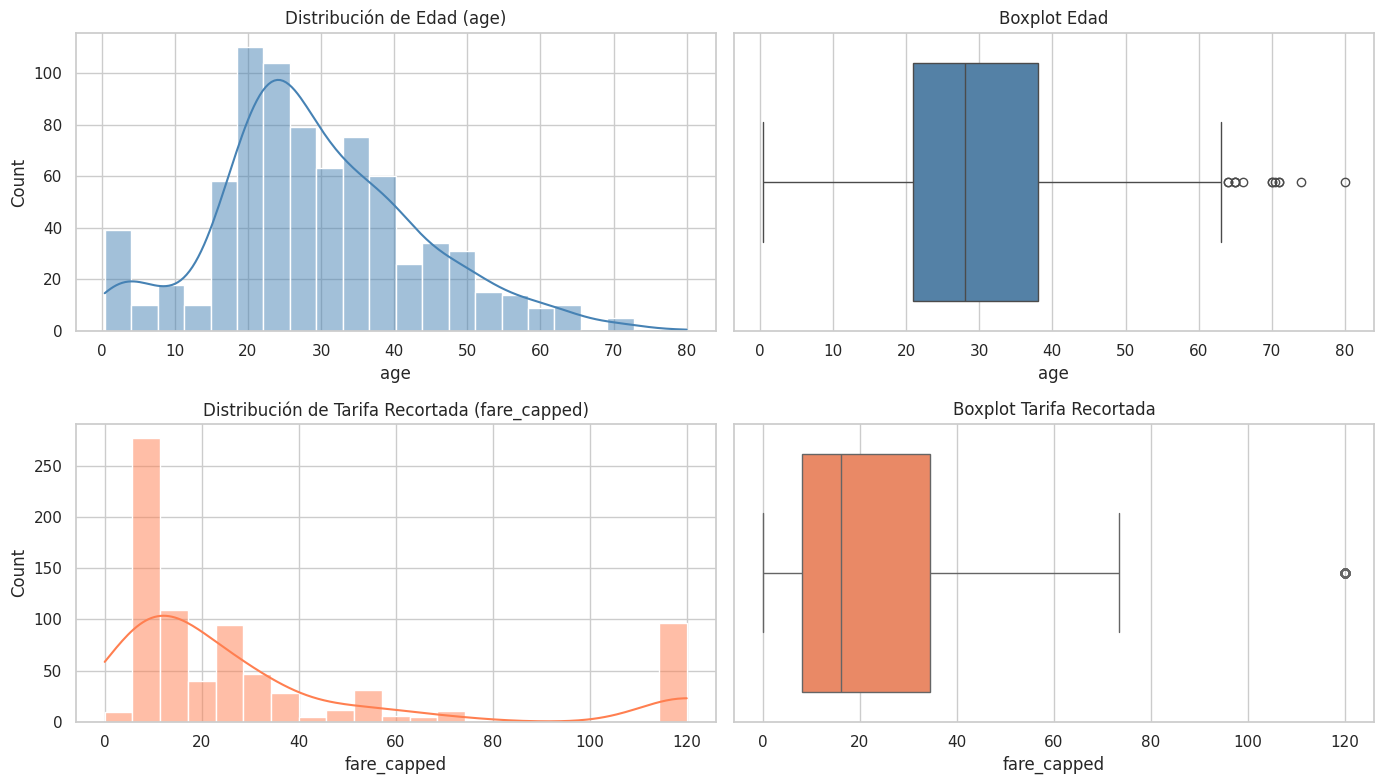

In [ ]:
forma_dist = pd.DataFrame({
    'Asimetría (Skewness)': df_limpio[['age', 'fare', 'fare_capped']].skew(),
    'Curtosis (Kurtosis)': df_limpio[['age', 'fare', 'fare_capped']].kurt()
})
display(forma_dist.round(2))

# Construcción de gráficos explicativos
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_limpio['age'], kde=True, ax=axes[0, 0], color='steelblue').set(title='Distribución de Edad (age)')
sns.boxplot(x=df_limpio['age'], ax=axes[0, 1], color='steelblue').set(title='Boxplot Edad')

sns.histplot(df_limpio['fare_capped'], kde=True, ax=axes[1, 0], color='coral').set(title='Distribución de Tarifa Recortada (fare_capped)')
sns.boxplot(x=df_limpio['fare_capped'], ax=axes[1, 1], color='coral').set(title='Boxplot Tarifa Recortada')

plt.tight_layout()
plt.show()

###Escalado de Variables Numéricas
Se realiza la transformación de las variables numéricas mediante dos técnicas estándar para facilitar el entrenamiento de modelos:

Normalización (Min-Max Scaling): Transforma los datos al rango [0, 1].

Estandarización (StandardScaler / Z-Score): Centra la media en 0 y la desviación estándar en 1.

In [ ]:
scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

df_limpio[['age_minmax', 'fare_minmax']] = scaler_minmax.fit_transform(df_limpio[['age', 'fare_capped']])
df_limpio[['age_zscore', 'fare_zscore']] = scaler_std.fit_transform(df_limpio[['age', 'fare_capped']])

print("Muestra comparativa de las variables originales y escaladas:")
display(df_limpio[['age', 'age_minmax', 'age_zscore', 'fare_capped', 'fare_minmax', 'fare_zscore']].head().round(3))

Muestra comparativa de las variables originales y escaladas:


,age,age_minmax,age_zscore,fare_capped,fare_minmax,fare_zscore
0,22.0,0.271,-0.541,7.250,0.060,-0.700
1,38.0,0.472,0.604,71.283,0.594,1.072
2,26.0,0.321,-0.255,7.925,0.066,-0.681
3,35.0,0.435,0.389,53.100,0.442,0.569
4,35.0,0.435,0.389,8.050,0.067,-0.678


###Análisis Integrador y Conclusiones
Se resume la relación de las variables transformadas con la tasa de supervivencia para sustentar las conclusiones del Módulo 2.

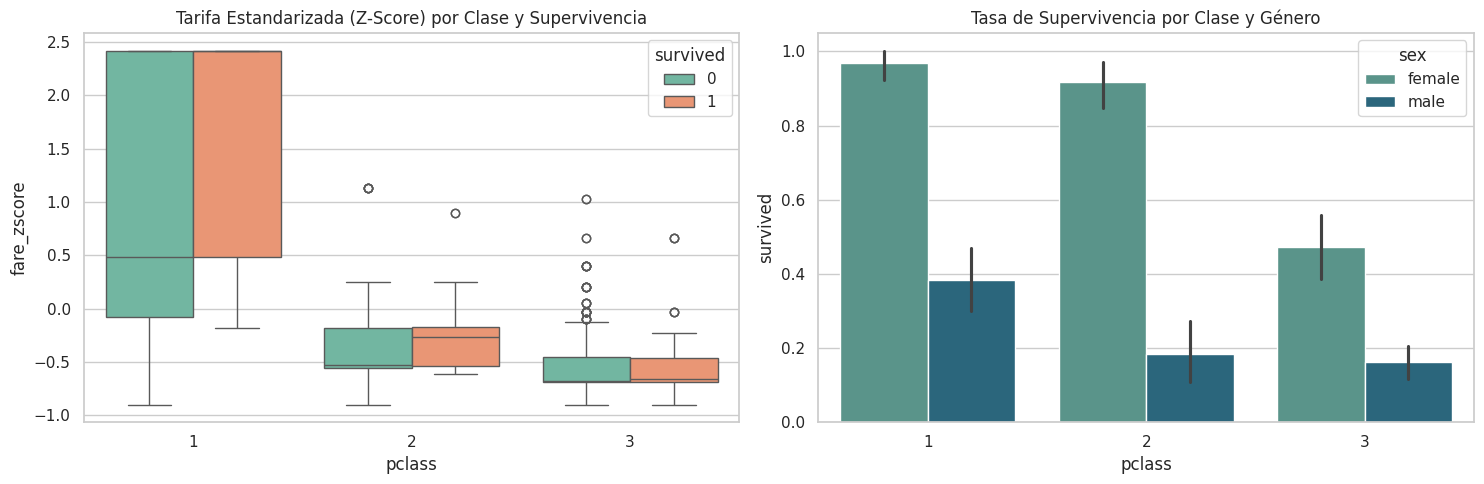

=== RESUMEN EJECUTIVO ===


,Clase,Género,Tasa_Supervivencia,Mediana_Edad,Media_Tarifa
0,1,female,0.97,35.0,96.60
1,1,male,0.38,40.0,61.40
2,2,female,0.92,28.0,22.32
3,2,male,0.18,30.0,21.55
4,3,female,0.47,21.5,15.70
5,3,male,0.16,25.0,12.82


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Tarifa estandarizada por clase y supervivencia
sns.boxplot(x='pclass', y='fare_zscore', hue='survived', data=df_limpio, ax=axes[0], palette='Set2')
axes[0].set_title('Tarifa Estandarizada (Z-Score) por Clase y Supervivencia')

# Gráfico 2: Supervivencia por clase y género
sns.barplot(x='pclass', y='survived', hue='sex', data=df_limpio, ax=axes[1], palette='crest')
axes[1].set_title('Tasa de Supervivencia por Clase y Género')

plt.tight_layout()
plt.show()

# Resumen ejecutivo tabulado
resumen = df_limpio.groupby(['pclass', 'sex'])[['survived', 'age', 'fare_capped']].agg({
    'survived': 'mean',
    'age': 'median',
    'fare_capped': 'mean'
}).reset_index()

resumen.columns = ['Clase', 'Género', 'Tasa_Supervivencia', 'Mediana_Edad', 'Media_Tarifa']
print("=== RESUMEN EJECUTIVO ===")
display(resumen.round(2))